Loading GoEmotions dataset...
Total training samples: 43410
Average labels per comment: 1.18


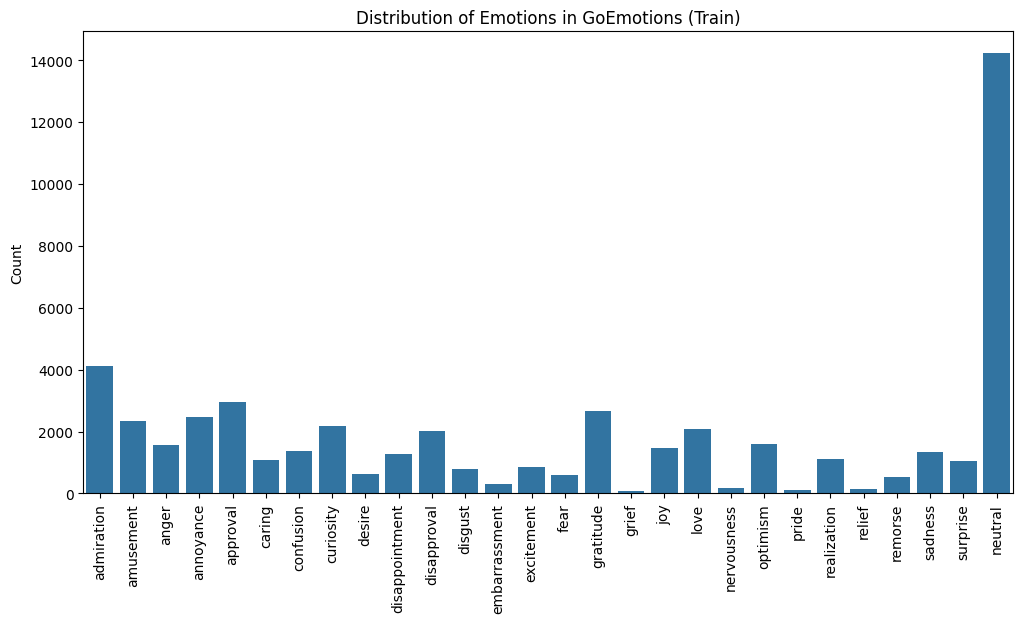

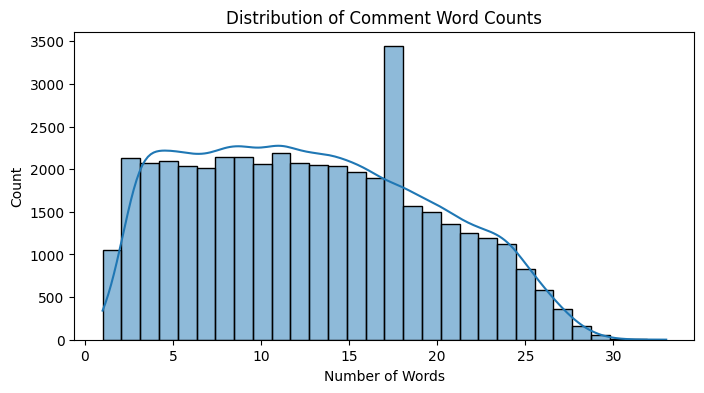


Sample Data:
Text: My favourite food is anything I didn't have to cook myself. | Labels: ['neutral']
Text: Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead | Labels: ['neutral']
Text: WHY THE FUCK IS BAYLESS ISOING | Labels: ['anger']


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# 1. Load Dataset
print("Loading GoEmotions dataset...")
dataset = load_dataset("go_emotions", "simplified")
df = pd.DataFrame(dataset['train'])

# 2. Map IDs to Names (for visualization)
labels = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral"
]

# 3. Basic Statistics
print(f"Total training samples: {len(df)}")
df['num_labels'] = df['labels'].apply(lambda x: len(x))
print(f"Average labels per comment: {df['num_labels'].mean():.2f}")

# 4. Label Distribution
# Explode the list of labels to count each occurrence
all_labels = df.explode('labels')
label_counts = all_labels['labels'].value_counts().sort_index()
label_names_counts = {labels[int(k)]: v for k, v in label_counts.items()}

plt.figure(figsize=(12, 6))
sns.barplot(x=list(label_names_counts.keys()), y=list(label_names_counts.values()))
plt.xticks(rotation=90)
plt.title("Distribution of Emotions in GoEmotions (Train)")
plt.ylabel("Count")
plt.show()

# 5. Text Length Analysis
df['text_len'] = df['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8, 4))
sns.histplot(df['text_len'], bins=30, kde=True)
plt.title("Distribution of Comment Word Counts")
plt.xlabel("Number of Words")
plt.show()

# 6. Sample Inspection
print("\nSample Data:")
for i in range(3):
    text = df.iloc[i]['text']
    current_labels = [labels[l] for l in df.iloc[i]['labels']]
    print(f"Text: {text} | Labels: {current_labels}")